<a href="https://colab.research.google.com/github/moonsejin315/Python/blob/%EC%8B%9C%EA%B0%81%EC%A7%80%EB%8A%A5%EC%9D%98_%EC%9D%B4%ED%95%B4%EC%99%80_%EC%9D%91%EC%9A%A9/MNIST_%EB%8D%B0%EC%9D%B4%ED%84%B0_%EB%A1%9C%EB%93%9C.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [9]:
import torchvision.datasets as dset
import torchvision.transforms as transforms
from torch.utils.data import DataLoader
from torch.autograd import Variable
import matplotlib.pyplot as plt
%matplotlib inline

torch.Size([1, 28, 28]) 5
torch.Size([1, 28, 28]) 0
60000
mnist_train길이 :  60000
5
torch.Size([1, 28, 28])


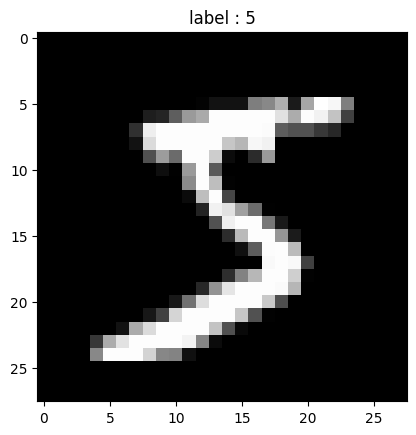

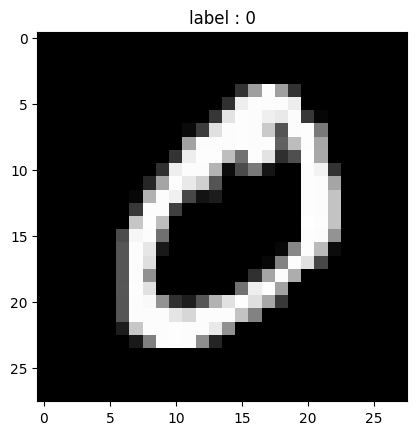

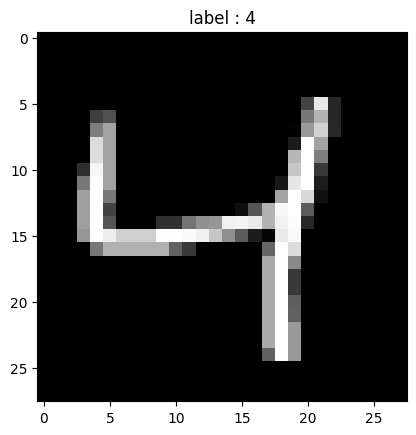

In [10]:
#1. MNIST 로드
mnist_train = dset.MNIST("", train=True, transform = transforms.ToTensor(), #train 용으로 쓰겠다.
                         target_transform=None, download=True)

#2. 그려보기
#MNIST data 하나 형태 출력
image, label = mnist_train.__getitem__(0)
print(image.size(), label)

image, label = mnist_train[1]
print(image.size(), label)

print(mnist_train.__len__())
print("mnist_train길이 : ", len(mnist_train))

#그리기
print(mnist_train[0][1]) #label
print(mnist_train[0][0].size()) #image

for i in range(3):
  img = mnist_train[i][0].numpy() #image 타입을 numpy로 변환(1,28,28)
  #print "label:", mnist_train[i][1]
  plt.title("label : %d" %mnist_train[i][1])
  plt.imshow(img[0], cmap='gray')
  plt.show()

In [11]:
#"": 현재 폴더에 MNIST 있음
mnist_train = dset.MNIST("", train = True, transform = transforms.ToTensor(), #train 용으로 쓰겠다.
                         target_transform=None, download=True)
mnist_test = dset.MNIST("", train = False, transform = transforms.ToTensor(), #test 용으로 쓰겠다.
                        target_transform=None, download=True)

mnist_train길이: 60000
mnist_test길이: 10000
image data 형태 :  torch.Size([1, 28, 28])
label :  5


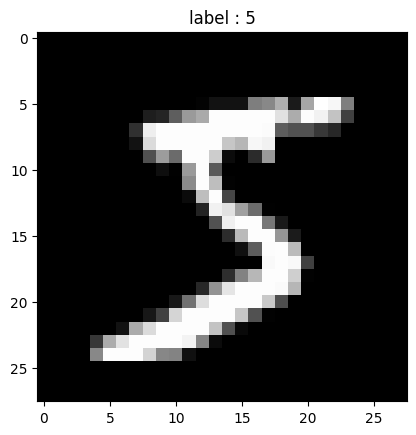

In [12]:
print("mnist_train길이:", len(mnist_train))
print("mnist_test길이:", len(mnist_test))

#데이터 하나 형태
image, label = mnist_train.__getitem__(0) #0번째 데이터
print("image data 형태 : ", image.size())
print("label : ", label)

#그리기
img = image.numpy()  #image 타입을 numpy로 변환 (1,28,28)
plt.title("label : %d" %label)
plt.imshow(img[0], cmap='gray')
plt.show()

In [13]:
batch_size = 16

In [16]:
train_loader = torch.utils.data.DataLoader(list(mnist_train)[:batch_size*100], batch_size=batch_size,
                                           #mnist_train를 트레인 시키자.
                                            shuffle=True, num_workers = 2,
                                           drop_last=True) #batch_size 만큼 나눌 때 나머지는 버려라
test_loader = torch.utils.data.DataLoader((mnist_test), batch_size = batch_size,
                                          shuffle=False, num_workers=2,
                                          drop_last=True)

/usr/lib/python3.10/multiprocessing/popen_fork.py:66: RuntimeWarning: os.fork() was called. os.fork() is incompatible with multithreaded code, and JAX is multithreaded, so this will likely lead to a deadlock.
  self.pid = os.fork()


[0]
한 번에 로드되는 데이터 크기 :  16
torch.Size([16, 28, 28])
torch.Size([16])


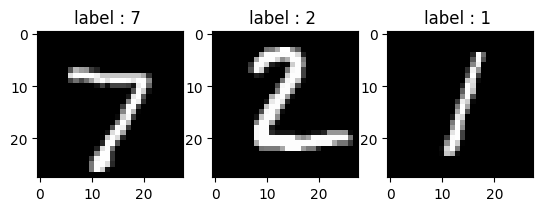

[1]
한 번에 로드되는 데이터 크기 :  16
torch.Size([16, 28, 28])
torch.Size([16])


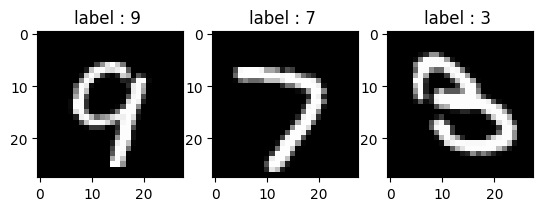

[2]
한 번에 로드되는 데이터 크기 :  16
torch.Size([16, 28, 28])
torch.Size([16])


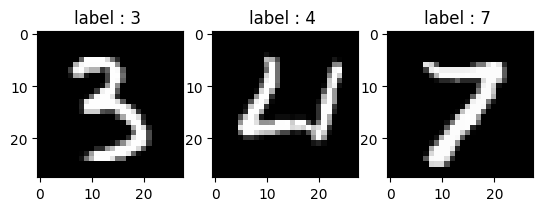

[3]
한 번에 로드되는 데이터 크기 :  16
torch.Size([16, 28, 28])
torch.Size([16])


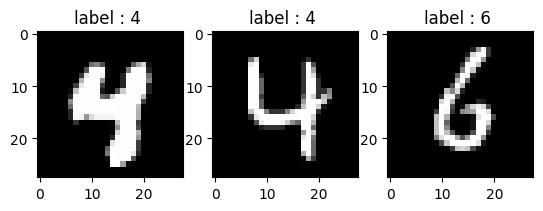

[4]
한 번에 로드되는 데이터 크기 :  16
torch.Size([16, 28, 28])
torch.Size([16])


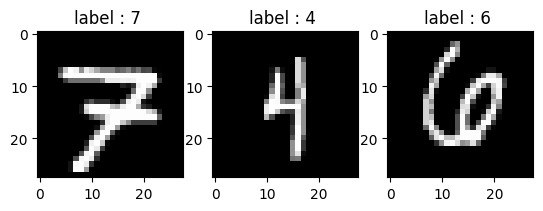

[5]
한 번에 로드되는 데이터 크기 :  16
torch.Size([16, 28, 28])
torch.Size([16])


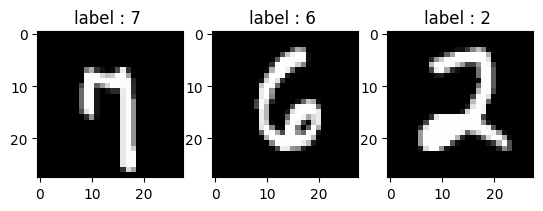

In [17]:
n = 3 #샘플로 그려볼 데이터 개수
for i, [imgs, labels] in enumerate(test_loader):  #batch_size 만큼
  if i>5:
    break

  print("[%d]" %i)
  print("한 번에 로드되는 데이터 크기 : ", len(imgs))

  #GPU 에 로드되기 위함. 만약 CPU로 설정되어 있다면 자동으로(?) CPU로 로드됨
  x = Variable(imgs) #.cuda() #(batch_size, 1,28,28)
  x = x.reshape((x.shape[0], x.shape[2], x.shape[3])) #(batch_size, 1, 28, 28) ->(batch_size, 28, 28)
  y_ = Variable(labels) #.cuda() #(batch_size)

  print(x.shape)
  print(y_.shape)

  #그리기
  for j in range(n):
    img = imgs[j].numpy() #image 타입을 numpy로 변환(1,28,28)
    img = img.reshape((img.shape[1], img.shape[2])) #(1,28,28) -> (28,28)
    #print(img.shape)

    plt.subplot(1, n, j+1) #(1,3) 형태 플랏의 j번째 자리에 그리겠다.
    plt.imshow(img, cmap = 'gray')
    plt.title("label : %d " %labels[j])
  plt.show()